# 1. Project Setup & Data Loading

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Daily_Demand_History.csv')

In [3]:
df

,Date,SKU,Warehouse,Product_Category,Demand_Units,Open,Promo,StateHoliday,SchoolHoliday,Petrol_price
0,2016-01-03,Product_0033,Whse_S,Category_005,16000,1,0,0,0,91
1,2016-01-03,Product_1825,Whse_S,Category_006,50000,1,0,0,0,85
2,2016-01-03,Product_0551,Whse_S,Category_030,3000,1,0,0,0,85
3,2016-01-03,Product_0556,Whse_S,Category_030,1000,1,0,0,0,93
4,2016-01-03,Product_1844,Whse_A,Category_018,7,1,0,0,0,95
...,...,...,...,...,...,...,...,...,...,...
169206,2016-11-23,Product_1368,Whse_A,Category_019,1400,0,0,a,1,84
169207,2016-11-23,Product_0094,Whse_S,Category_019,5000,0,0,a,1,80
169208,2016-11-23,Product_2074,Whse_A,Category_009,40,0,0,a,1,81
169209,2016-11-23,Product_2074,Whse_A,Category_009,10,0,0,a,1,83


# 2. Exploratory Data Analysis (EDA)

In [4]:
df.shape

(169211, 10)

In [5]:
df.head()

,Date,SKU,Warehouse,Product_Category,Demand_Units,Open,Promo,StateHoliday,SchoolHoliday,Petrol_price
0,2016-01-03,Product_0033,Whse_S,Category_005,16000,1,0,0,0,91
1,2016-01-03,Product_1825,Whse_S,Category_006,50000,1,0,0,0,85
2,2016-01-03,Product_0551,Whse_S,Category_030,3000,1,0,0,0,85
3,2016-01-03,Product_0556,Whse_S,Category_030,1000,1,0,0,0,93
4,2016-01-03,Product_1844,Whse_A,Category_018,7,1,0,0,0,95


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169211 entries, 0 to 169210
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Date              169211 non-null  object
 1   SKU               169211 non-null  object
 2   Warehouse         169211 non-null  object
 3   Product_Category  169211 non-null  object
 4   Demand_Units      169211 non-null  int64 
 5   Open              169211 non-null  int64 
 6   Promo             169211 non-null  int64 
 7   StateHoliday      169211 non-null  object
 8   SchoolHoliday     169211 non-null  int64 
 9   Petrol_price      169211 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 12.9+ MB


In [7]:
# Converting Date column to Datetime
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
df['StateHoliday'].unique()

array(['0', 'a', 'b'], dtype=object)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169211 entries, 0 to 169210
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Date              169211 non-null  datetime64[ns]
 1   SKU               169211 non-null  object        
 2   Warehouse         169211 non-null  object        
 3   Product_Category  169211 non-null  object        
 4   Demand_Units      169211 non-null  int64         
 5   Open              169211 non-null  int64         
 6   Promo             169211 non-null  int64         
 7   StateHoliday      169211 non-null  object        
 8   SchoolHoliday     169211 non-null  int64         
 9   Petrol_price      169211 non-null  int64         
dtypes: datetime64[ns](1), int64(5), object(4)
memory usage: 12.9+ MB


In [10]:
df.describe()

,Date,Demand_Units,Open,Promo,SchoolHoliday,Petrol_price
count,169211,1.692110e+05,169211.000000,169211.000000,169211.000000,169211.000000
mean,2016-06-13 07:36:07.922889216,5.248118e+03,0.817742,0.395364,0.133401,87.986183
min,2016-01-03 00:00:00,0.000000e+00,0.000000,0.000000,0.000000,80.000000
25%,2016-03-22 00:00:00,2.000000e+01,1.000000,0.000000,0.000000,84.000000
50%,2016-06-14 00:00:00,3.000000e+02,1.000000,0.000000,0.000000,88.000000
75%,2016-09-05 00:00:00,2.000000e+03,1.000000,1.000000,0.000000,92.000000
max,2016-11-23 00:00:00,2.500000e+06,1.000000,1.000000,1.000000,96.000000
std,NaN,3.116296e+04,0.386058,0.488930,0.340009,4.909978


In [11]:
df.isnull().sum()

Date                0
SKU                 0
Warehouse           0
Product_Category    0
Demand_Units        0
Open                0
Promo               0
StateHoliday        0
SchoolHoliday       0
Petrol_price        0
dtype: int64

In [12]:
df.columns

Index(['Date', 'SKU', 'Warehouse', 'Product_Category', 'Demand_Units', 'Open',
       'Promo', 'StateHoliday', 'SchoolHoliday', 'Petrol_price'],
      dtype='object')

In [13]:
numeric_columns = ['Demand_Units', 'Open', 'Promo', 'SchoolHoliday', 'Petrol_price' ]

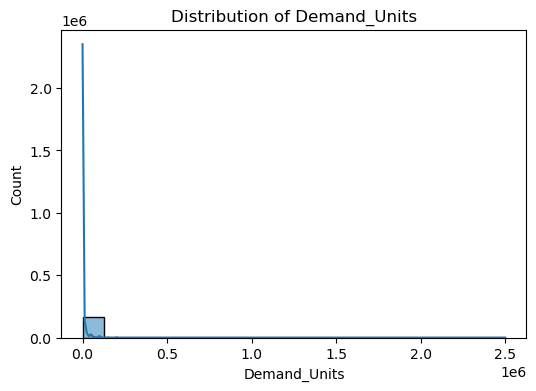

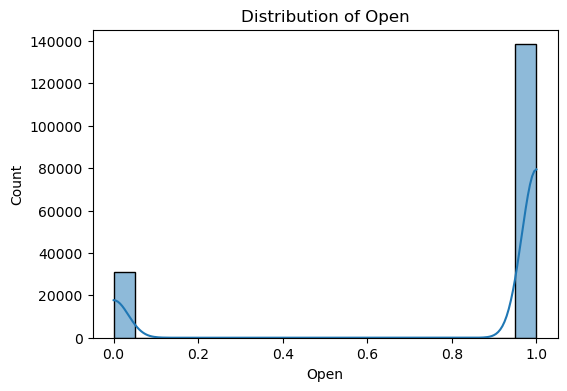

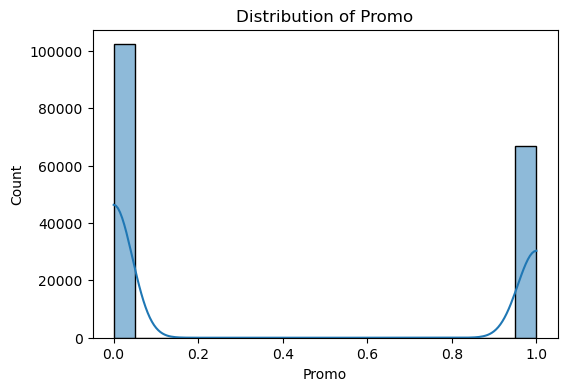

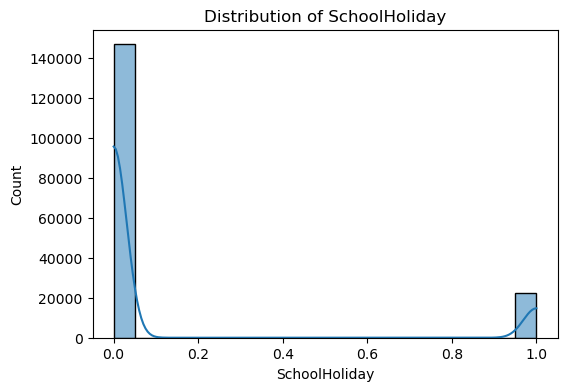

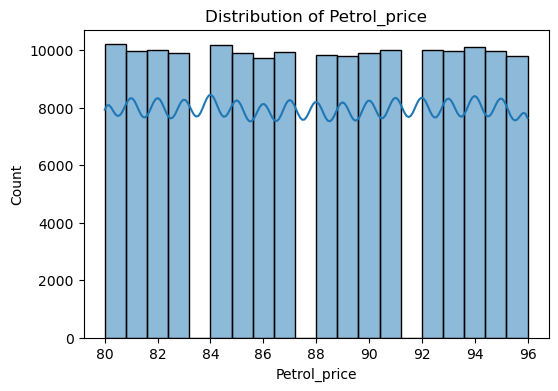

In [14]:
for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

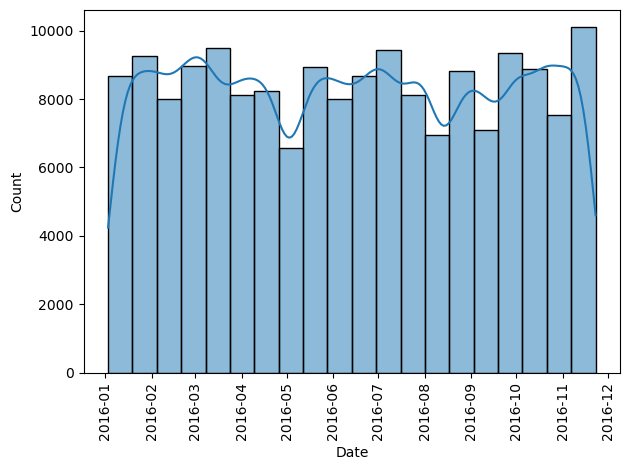

In [15]:
sns.histplot(x = df['Date'], kde=True, bins=20)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

<Axes: xlabel='Warehouse', ylabel='count'>

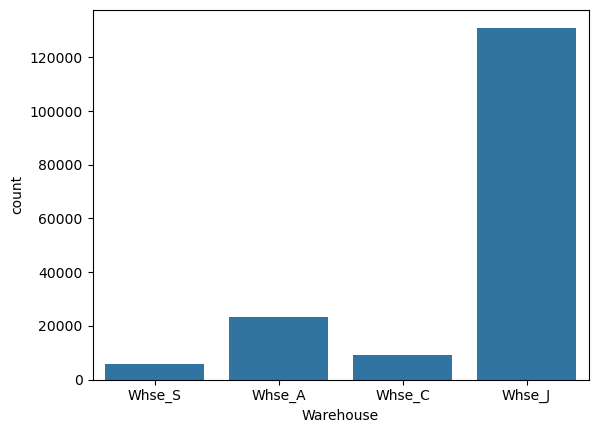

In [16]:
sns.countplot(x = df['Warehouse'])

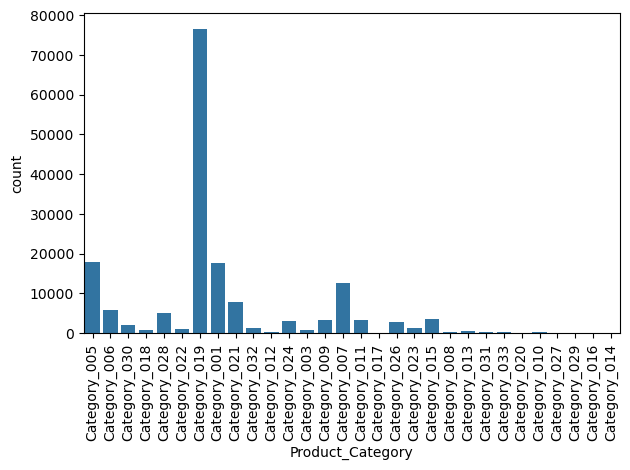

In [17]:
sns.countplot(x = df['Product_Category'])
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

<Axes: xlabel='StateHoliday', ylabel='count'>

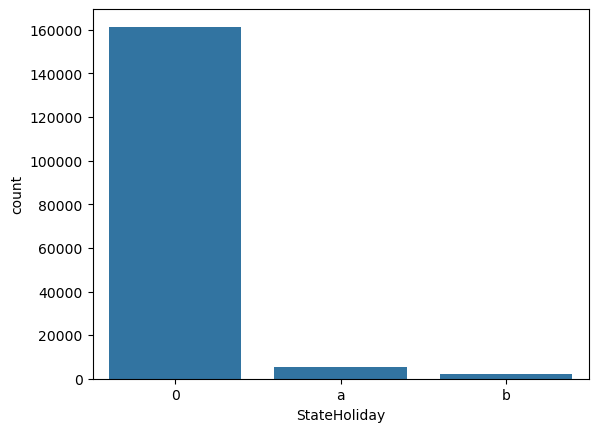

In [18]:
sns.countplot(x = df['StateHoliday'])

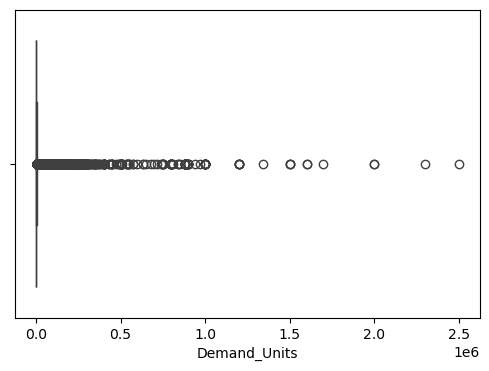

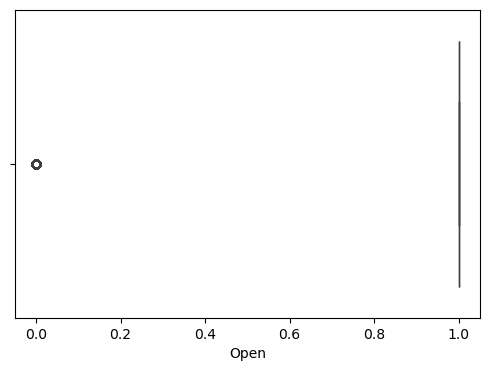

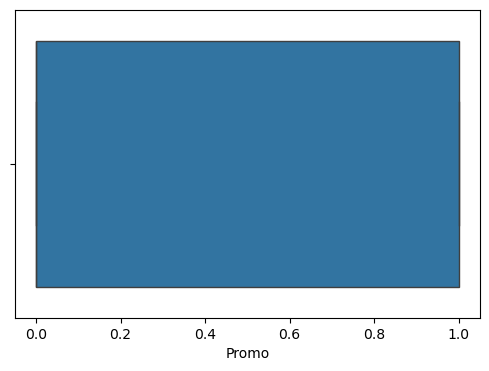

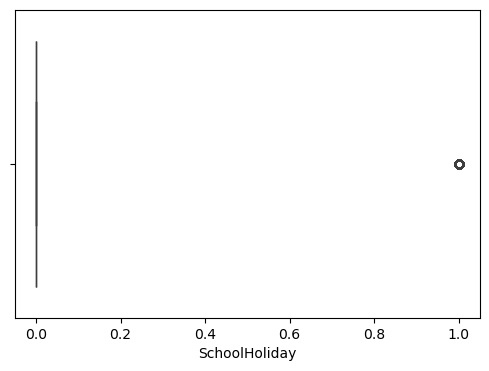

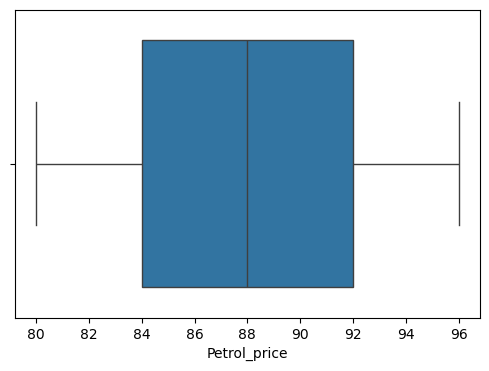

In [19]:
for col in numeric_columns:
    plt.figure(figsize= (6,4))
    sns.boxplot(x = df[col])
    plt.show()

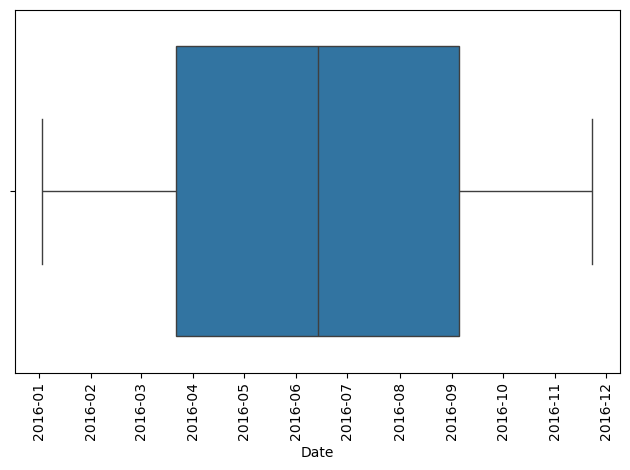

In [20]:
sns.boxplot(x = df['Date'])
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

<Axes: >

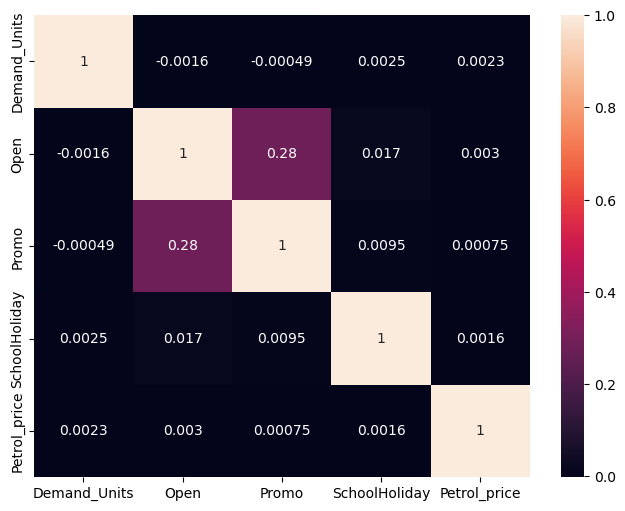

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

# 3. Data Cleaning & Quality Checks

In [22]:
df_cleaned = df.copy()

In [23]:
df_cleaned.head()

,Date,SKU,Warehouse,Product_Category,Demand_Units,Open,Promo,StateHoliday,SchoolHoliday,Petrol_price
0,2016-01-03,Product_0033,Whse_S,Category_005,16000,1,0,0,0,91
1,2016-01-03,Product_1825,Whse_S,Category_006,50000,1,0,0,0,85
2,2016-01-03,Product_0551,Whse_S,Category_030,3000,1,0,0,0,85
3,2016-01-03,Product_0556,Whse_S,Category_030,1000,1,0,0,0,93
4,2016-01-03,Product_1844,Whse_A,Category_018,7,1,0,0,0,95


In [24]:
df_cleaned.shape

(169211, 10)

In [25]:
df_cleaned.drop_duplicates(inplace = True)

In [26]:
df_cleaned.shape

(168262, 10)

In [27]:
df_cleaned.isnull().sum()

Date                0
SKU                 0
Warehouse           0
Product_Category    0
Demand_Units        0
Open                0
Promo               0
StateHoliday        0
SchoolHoliday       0
Petrol_price        0
dtype: int64

In [28]:
# Negative demand check
negative_demand = (df_cleaned['Demand_Units'] < 0).sum()
print(f"Negative Demand count: {negative_demand}")

Negative Demand count: 0


In [29]:
df_cleaned.dtypes

Date                datetime64[ns]
SKU                         object
Warehouse                   object
Product_Category            object
Demand_Units                 int64
Open                         int64
Promo                        int64
StateHoliday                object
SchoolHoliday                int64
Petrol_price                 int64
dtype: object

In [30]:
# Analyze the quantile distribution of target variable (Demand_Units)
quantiles = df_cleaned['Demand_Units'].quantile([0.5, 0.9, 0.95, 0.99, 0.999, 1.0])
print("Target Variable Quantile Distribution:")
print(quantiles)

# Calculate 99.9th percentile threshold for potential capping/Winsorization
cap_value = df_cleaned['Demand_Units'].quantile(0.999)
print(f"\n99.9th Percentile Cap Threshold Value: {cap_value:,.2f}")

Target Variable Quantile Distribution:
0.500        300.0
0.900      10000.0
0.950      20000.0
0.990      80000.0
0.999     400000.0
1.000    2500000.0
Name: Demand_Units, dtype: float64

99.9th Percentile Cap Threshold Value: 400,000.00


In [31]:
# Filter and inspect records with maximum demand (2,500,000 units)
extreme_outlier_mask = df_cleaned['Demand_Units'] == 2500000
extreme_outlier_count = extreme_outlier_mask.sum()

print(f"Total entries identified with 2,500,000 demand: {extreme_outlier_count}")

Total entries identified with 2,500,000 demand: 1


In [32]:
# Display detailed attributes of the erroneous entry
erroneous_records = df_cleaned[extreme_outlier_mask]
print("\nErroneous Entry Details:")
print(erroneous_records[['Date', 'SKU', 'Warehouse', 'Demand_Units', 'Open']])


Erroneous Entry Details:
             Date           SKU Warehouse  Demand_Units  Open
108772 2016-07-29  Product_1432    Whse_S       2500000     0


In [33]:
# Record shape before removal
rows_before = len(df_cleaned)

# Drop the erroneous record where Demand_Units is 2,500,000 (logged when Warehouse was Closed)
df_cleaned = df_cleaned[df_cleaned['Demand_Units'] < 2500000].reset_index(drop=True)

# Verify successful removal
rows_after = len(df_cleaned)
print(f"Dataset Shape Before Removal : {rows_before}")
print(f"Dataset Shape After Removal  : {rows_after}")
print(f"Total Rows Removed           : {rows_before - rows_after}")

Dataset Shape Before Removal : 168262
Dataset Shape After Removal  : 168261
Total Rows Removed           : 1


In [34]:
# Set Demand_Units to 0 whenever the Warehouse is Closed (Open == 0)
df_cleaned.loc[df_cleaned['Open'] == 0, 'Demand_Units'] = 0

# Verification: Check if any non-zero demand units remain when Open == 0
closed_rows = (df_cleaned['Open'] == 0).sum()
non_zero_closed_demand = (df_cleaned[df_cleaned['Open'] == 0]['Demand_Units'] != 0).sum()

print(f"Total Closed Warehouse Records (Open = 0) : {closed_rows}")
print(f"Non-Zero Demand Units in Closed Records   : {non_zero_closed_demand}")

Total Closed Warehouse Records (Open = 0) : 30699
Non-Zero Demand Units in Closed Records   : 0


In [35]:
df_cleaned['StateHoliday'].value_counts()

StateHoliday
0    160529
a      5510
b      2222
Name: count, dtype: int64

In [36]:
df_cleaned['StateHoliday'] = df_cleaned['StateHoliday'].astype(str).replace({'0': 0, 'a': 1, 'b': 2})

In [37]:
df_cleaned['StateHoliday'].value_counts()

StateHoliday
0    160529
1      5510
2      2222
Name: count, dtype: int64

In [38]:
df_cleaned.head()

,Date,SKU,Warehouse,Product_Category,Demand_Units,Open,Promo,StateHoliday,SchoolHoliday,Petrol_price
0,2016-01-03,Product_0033,Whse_S,Category_005,16000,1,0,0,0,91
1,2016-01-03,Product_1825,Whse_S,Category_006,50000,1,0,0,0,85
2,2016-01-03,Product_0551,Whse_S,Category_030,3000,1,0,0,0,85
3,2016-01-03,Product_0556,Whse_S,Category_030,1000,1,0,0,0,93
4,2016-01-03,Product_1844,Whse_A,Category_018,7,1,0,0,0,95


# 4. Feature Engineering & Transformations

In [39]:
df_cleaned.head()

,Date,SKU,Warehouse,Product_Category,Demand_Units,Open,Promo,StateHoliday,SchoolHoliday,Petrol_price
0,2016-01-03,Product_0033,Whse_S,Category_005,16000,1,0,0,0,91
1,2016-01-03,Product_1825,Whse_S,Category_006,50000,1,0,0,0,85
2,2016-01-03,Product_0551,Whse_S,Category_030,3000,1,0,0,0,85
3,2016-01-03,Product_0556,Whse_S,Category_030,1000,1,0,0,0,93
4,2016-01-03,Product_1844,Whse_A,Category_018,7,1,0,0,0,95


## 4.1 Target Skewness Handling

In [40]:
# Skewness check before transformation
raw_skew = df_cleaned['Demand_Units'].skew()
print(f"Original Demand_Units Skewness: {raw_skew:.4f}")

Original Demand_Units Skewness: 30.0433


In [41]:
# Appling log1p transformation
df_cleaned['Log_Demand_Units'] = np.log1p(df_cleaned['Demand_Units'])
# Skewness check after transformation
log_skew = df_cleaned['Log_Demand_Units'].skew()
print(f"Log1p Transformed Skewness   : {log_skew:.4f}")

Log1p Transformed Skewness   : 0.0823


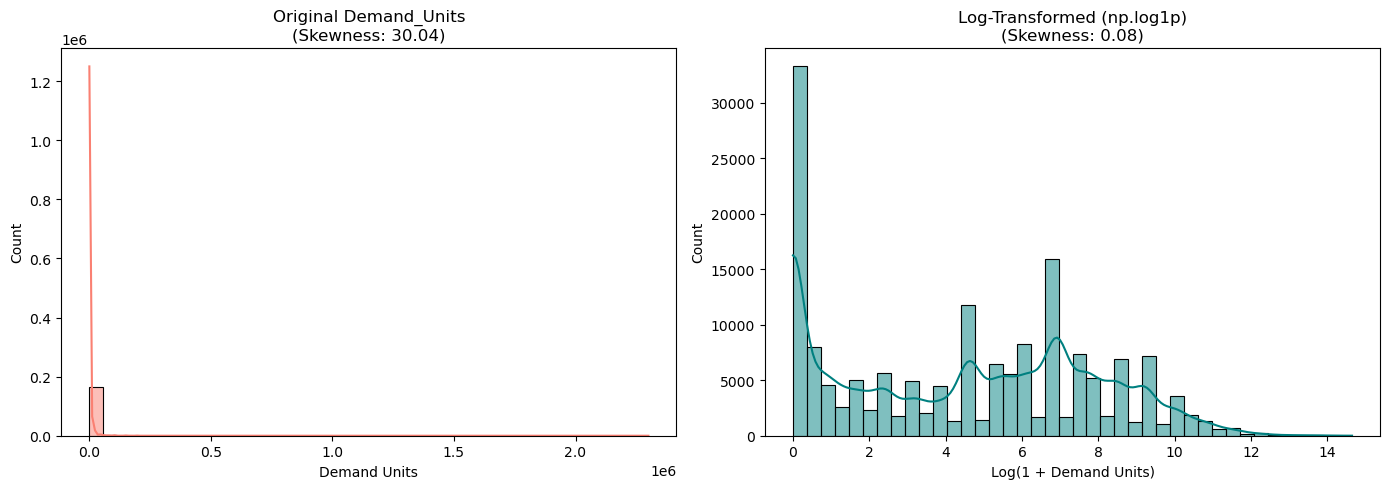

In [42]:
# Before vs After Comparison Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original Distribution
sns.histplot(df_cleaned['Demand_Units'], bins=40, kde=True, ax=axes[0], color='salmon')
axes[0].set_title(f'Original Demand_Units\n(Skewness: {raw_skew:.2f})')
axes[0].set_xlabel('Demand Units')

# Log Transformed Distribution
sns.histplot(df_cleaned['Log_Demand_Units'], bins=40, kde=True, ax=axes[1], color='teal')
axes[1].set_title(f'Log-Transformed (np.log1p)\n(Skewness: {log_skew:.2f})')
axes[1].set_xlabel('Log(1 + Demand Units)')
plt.tight_layout()
plt.show()

In [43]:
df_cleaned.head()

,Date,SKU,Warehouse,Product_Category,Demand_Units,Open,Promo,StateHoliday,SchoolHoliday,Petrol_price,Log_Demand_Units
0,2016-01-03,Product_0033,Whse_S,Category_005,16000,1,0,0,0,91,9.680406
1,2016-01-03,Product_1825,Whse_S,Category_006,50000,1,0,0,0,85,10.819798
2,2016-01-03,Product_0551,Whse_S,Category_030,3000,1,0,0,0,85,8.006701
3,2016-01-03,Product_0556,Whse_S,Category_030,1000,1,0,0,0,93,6.908755
4,2016-01-03,Product_1844,Whse_A,Category_018,7,1,0,0,0,95,2.079442


## 4.2 Categorical Encoding

In [44]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['Warehouse'],drop_first=True)

In [45]:
# Convert Warehouse dummies from True/False to 1/0
bool_cols = df_cleaned.select_dtypes(include='bool').columns
df_cleaned[bool_cols] = df_cleaned[bool_cols].astype(int)

# Verify types and values
print("Updated Data Types:")
print(df_cleaned[bool_cols].dtypes)


Updated Data Types:
Warehouse_Whse_C    int64
Warehouse_Whse_J    int64
Warehouse_Whse_S    int64
dtype: object


In [46]:
df_cleaned.head()

,Date,SKU,Product_Category,Demand_Units,Open,Promo,StateHoliday,SchoolHoliday,Petrol_price,Log_Demand_Units,Warehouse_Whse_C,Warehouse_Whse_J,Warehouse_Whse_S
0,2016-01-03,Product_0033,Category_005,16000,1,0,0,0,91,9.680406,0,0,1
1,2016-01-03,Product_1825,Category_006,50000,1,0,0,0,85,10.819798,0,0,1
2,2016-01-03,Product_0551,Category_030,3000,1,0,0,0,85,8.006701,0,0,1
3,2016-01-03,Product_0556,Category_030,1000,1,0,0,0,93,6.908755,0,0,1
4,2016-01-03,Product_1844,Category_018,7,1,0,0,0,95,2.079442,0,0,0


In [47]:
# 1. Label Encoding (Integer ID for SKU and Category)
df_cleaned['SKU_Code'] = df_cleaned['SKU'].astype('category').cat.codes
df_cleaned['Category_Code'] = df_cleaned['Product_Category'].astype('category').cat.codes

In [48]:
df_cleaned.head()

,Date,SKU,Product_Category,Demand_Units,Open,Promo,StateHoliday,SchoolHoliday,Petrol_price,Log_Demand_Units,Warehouse_Whse_C,Warehouse_Whse_J,Warehouse_Whse_S,SKU_Code,Category_Code
0,2016-01-03,Product_0033,Category_005,16000,1,0,0,0,91,9.680406,0,0,1,32,2
1,2016-01-03,Product_1825,Category_006,50000,1,0,0,0,85,10.819798,0,0,1,1772,3
2,2016-01-03,Product_0551,Category_030,3000,1,0,0,0,85,8.006701,0,0,1,543,26
3,2016-01-03,Product_0556,Category_030,1000,1,0,0,0,93,6.908755,0,0,1,548,26
4,2016-01-03,Product_1844,Category_018,7,1,0,0,0,95,2.079442,0,0,0,1791,15


In [49]:
# 2. Historical Demand Features for SKU (Fast-moving vs Slow-moving items)
sku_stats = df_cleaned.groupby('SKU')['Demand_Units'].agg(
    SKU_Mean_Demand='mean',
    SKU_Median_Demand='median',
    SKU_Order_Frequency='count'
).reset_index()

# Merge SKU stats back to df_cleaned
df_cleaned = df_cleaned.merge(sku_stats, on='SKU', how='left')

In [50]:
df_cleaned.head()

,Date,SKU,Product_Category,Demand_Units,Open,Promo,StateHoliday,SchoolHoliday,Petrol_price,Log_Demand_Units,Warehouse_Whse_C,Warehouse_Whse_J,Warehouse_Whse_S,SKU_Code,Category_Code,SKU_Mean_Demand,SKU_Median_Demand,SKU_Order_Frequency
0,2016-01-03,Product_0033,Category_005,16000,1,0,0,0,91,9.680406,0,0,1,32,2,7858.757062,1500.0,708
1,2016-01-03,Product_1825,Category_006,50000,1,0,0,0,85,10.819798,0,0,1,1772,3,11107.594937,2500.0,316
2,2016-01-03,Product_0551,Category_030,3000,1,0,0,0,85,8.006701,0,0,1,543,26,615.384615,500.0,39
3,2016-01-03,Product_0556,Category_030,1000,1,0,0,0,93,6.908755,0,0,1,548,26,5718.181818,1500.0,55
4,2016-01-03,Product_1844,Category_018,7,1,0,0,0,95,2.079442,0,0,0,1791,15,6.653061,6.0,49


In [51]:
# 3. Historical Category-level Average Demand
cat_stats = df_cleaned.groupby('Product_Category')['Demand_Units'].agg(
    Category_Mean_Demand='mean'
).reset_index()

# Merge Category stats back to df_cleaned
df_cleaned = df_cleaned.merge(cat_stats, on='Product_Category', how='left')

In [52]:
df_cleaned.head()

,Date,SKU,Product_Category,Demand_Units,Open,Promo,StateHoliday,SchoolHoliday,Petrol_price,Log_Demand_Units,Warehouse_Whse_C,Warehouse_Whse_J,Warehouse_Whse_S,SKU_Code,Category_Code,SKU_Mean_Demand,SKU_Median_Demand,SKU_Order_Frequency,Category_Mean_Demand
0,2016-01-03,Product_0033,Category_005,16000,1,0,0,0,91,9.680406,0,0,1,32,2,7858.757062,1500.0,708,1476.765419
1,2016-01-03,Product_1825,Category_006,50000,1,0,0,0,85,10.819798,0,0,1,1772,3,11107.594937,2500.0,316,10719.771897
2,2016-01-03,Product_0551,Category_030,3000,1,0,0,0,85,8.006701,0,0,1,543,26,615.384615,500.0,39,2071.740533
3,2016-01-03,Product_0556,Category_030,1000,1,0,0,0,93,6.908755,0,0,1,548,26,5718.181818,1500.0,55,2071.740533
4,2016-01-03,Product_1844,Category_018,7,1,0,0,0,95,2.079442,0,0,0,1791,15,6.653061,6.0,49,6.292056


In [53]:
# Preview the engineered features
df_cleaned[['SKU', 'SKU_Code', 'SKU_Mean_Demand', 'Product_Category', 'Category_Code', 'Category_Mean_Demand']].head()

,SKU,SKU_Code,SKU_Mean_Demand,Product_Category,Category_Code,Category_Mean_Demand
0,Product_0033,32,7858.757062,Category_005,2,1476.765419
1,Product_1825,1772,11107.594937,Category_006,3,10719.771897
2,Product_0551,543,615.384615,Category_030,26,2071.740533
3,Product_0556,548,5718.181818,Category_030,26,2071.740533
4,Product_1844,1791,6.653061,Category_018,15,6.292056


## 4.3 Date & Calendar Features

In [54]:
df_cleaned.head()

,Date,SKU,Product_Category,Demand_Units,Open,Promo,StateHoliday,SchoolHoliday,Petrol_price,Log_Demand_Units,Warehouse_Whse_C,Warehouse_Whse_J,Warehouse_Whse_S,SKU_Code,Category_Code,SKU_Mean_Demand,SKU_Median_Demand,SKU_Order_Frequency,Category_Mean_Demand
0,2016-01-03,Product_0033,Category_005,16000,1,0,0,0,91,9.680406,0,0,1,32,2,7858.757062,1500.0,708,1476.765419
1,2016-01-03,Product_1825,Category_006,50000,1,0,0,0,85,10.819798,0,0,1,1772,3,11107.594937,2500.0,316,10719.771897
2,2016-01-03,Product_0551,Category_030,3000,1,0,0,0,85,8.006701,0,0,1,543,26,615.384615,500.0,39,2071.740533
3,2016-01-03,Product_0556,Category_030,1000,1,0,0,0,93,6.908755,0,0,1,548,26,5718.181818,1500.0,55,2071.740533
4,2016-01-03,Product_1844,Category_018,7,1,0,0,0,95,2.079442,0,0,0,1791,15,6.653061,6.0,49,6.292056


In [55]:
df_cleaned['Day'] = df_cleaned['Date'].dt.day
df_cleaned['Month'] = df_cleaned['Date'].dt.month
df_cleaned['Quarter'] = df_cleaned['Date'].dt.quarter
df_cleaned['Week'] = df_cleaned['Date'].dt.isocalendar().week.astype(int)
df_cleaned['DayOfWeek'] = df_cleaned['Date'].dt.dayofweek          # 0 = Monday, 6 = Sunday
df_cleaned['IsWeekend'] = df_cleaned['DayOfWeek'].isin([5, 6]).astype(int)

df_cleaned[['Date', 'Day', 'Month', 'Quarter', 'Week', 'DayOfWeek', 'IsWeekend']]

,Date,Day,Month,Quarter,Week,DayOfWeek,IsWeekend
0,2016-01-03,3,1,1,53,6,1
1,2016-01-03,3,1,1,53,6,1
2,2016-01-03,3,1,1,53,6,1
3,2016-01-03,3,1,1,53,6,1
4,2016-01-03,3,1,1,53,6,1
...,...,...,...,...,...,...,...
168256,2016-11-23,23,11,4,47,2,0
168257,2016-11-23,23,11,4,47,2,0
168258,2016-11-23,23,11,4,47,2,0
168259,2016-11-23,23,11,4,47,2,0


## 4.4 Sorting & Time-Series Lags & Rolling Features

In [56]:
# Chronological sort by SKU and Date (Essential for accurate lags)
df_cleaned = df_cleaned.sort_values(by=['SKU', 'Date']).reset_index(drop=True)

In [57]:
# Lag Features (Past Demand)
lags = [1, 7, 14, 30]
for lag in lags:
    df_cleaned[f'Lag_{lag}'] = df_cleaned.groupby('SKU')['Demand_Units'].shift(lag)

In [58]:
# Rolling Means (Short-term & Long-term Trends)
for window in [7, 14, 30]:
    df_cleaned[f'RollingMean{window}'] = df_cleaned.groupby('SKU')['Demand_Units'].transform(
        lambda x: x.shift(1).rolling(window, min_periods=1).mean()
    )

In [59]:
# Demand Variability (Rolling Standard Deviation)
for window in [7, 30]:
    df_cleaned[f'RollingStd{window}'] = df_cleaned.groupby('SKU')['Demand_Units'].transform(
        lambda x: x.shift(1).rolling(window, min_periods=1).std()
    )

In [60]:
df_cleaned

,Date,SKU,Product_Category,Demand_Units,Open,Promo,StateHoliday,SchoolHoliday,Petrol_price,Log_Demand_Units,...,IsWeekend,Lag_1,Lag_7,Lag_14,Lag_30,RollingMean7,RollingMean14,RollingMean30,RollingStd7,RollingStd30
0,2016-01-05,Product_0001,Category_005,300,1,0,0,0,92,5.707110,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-01-05,Product_0001,Category_005,300,1,0,0,0,84,5.707110,...,0,300.0,NaN,NaN,NaN,300.000000,300.000000,300.000000,NaN,NaN
2,2016-01-07,Product_0001,Category_005,0,0,1,1,1,85,0.000000,...,0,300.0,NaN,NaN,NaN,300.000000,300.000000,300.000000,0.000000,0.000000
3,2016-01-08,Product_0001,Category_005,200,1,1,0,0,86,5.303305,...,0,0.0,NaN,NaN,NaN,200.000000,200.000000,200.000000,173.205081,173.205081
4,2016-01-15,Product_0001,Category_005,0,0,0,0,0,94,0.000000,...,0,200.0,NaN,NaN,NaN,200.000000,200.000000,200.000000,141.421356,141.421356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168256,2016-09-26,Product_2172,Category_005,900,1,0,0,0,89,6.803505,...,0,600.0,200.0,0.0,NaN,271.428571,314.285714,275.000000,228.868854,284.018779
168257,2016-09-27,Product_2172,Category_005,200,1,0,0,0,86,5.303305,...,0,900.0,500.0,600.0,NaN,371.428571,378.571429,311.764706,325.137334,314.011053
168258,2016-09-30,Product_2172,Category_005,0,0,0,0,0,87,0.000000,...,0,200.0,300.0,100.0,NaN,328.571429,350.000000,305.555556,325.137334,305.772353
168259,2016-10-21,Product_2172,Category_005,600,1,0,0,0,81,6.398595,...,0,0.0,0.0,300.0,NaN,285.714286,342.857143,289.473684,348.466026,305.313567


## 4.5 Handle NaNs in Lag & Rolling Features

In [61]:
# Imputing NaNs values in Lag and Rolling Mean features using the historical average demand per SKU (SKU_Mean_Demand)
for lag in [1, 7, 14, 30]:
    df_cleaned[f'Lag_{lag}'] = df_cleaned[f'Lag_{lag}'].fillna(df_cleaned['SKU_Mean_Demand'])
for window in [7, 14, 30]:
    df_cleaned[f'RollingMean{window}'] = df_cleaned[f'RollingMean{window}'].fillna(df_cleaned['SKU_Mean_Demand'])

In [62]:
# Filling NaNs values in Rolling Standard Deviation with 0 (assuming zero initial variance)
for window in [7, 30]:
    df_cleaned[f'RollingStd{window}'] = df_cleaned[f'RollingStd{window}'].fillna(0)

In [63]:
# Verifing that no null values remain across any of the engineered features
engineered_cols = [
    'Lag_1', 'Lag_7', 'Lag_14', 'Lag_30',
    'RollingMean7', 'RollingMean14', 'RollingMean30',
    'RollingStd7', 'RollingStd30'
]
print("Null values remaining in engineered features:")
print(df_cleaned[engineered_cols].isnull().sum())

Null values remaining in engineered features:
Lag_1            0
Lag_7            0
Lag_14           0
Lag_30           0
RollingMean7     0
RollingMean14    0
RollingMean30    0
RollingStd7      0
RollingStd30     0
dtype: int64


In [64]:
df_cleaned

,Date,SKU,Product_Category,Demand_Units,Open,Promo,StateHoliday,SchoolHoliday,Petrol_price,Log_Demand_Units,...,IsWeekend,Lag_1,Lag_7,Lag_14,Lag_30,RollingMean7,RollingMean14,RollingMean30,RollingStd7,RollingStd30
0,2016-01-05,Product_0001,Category_005,300,1,0,0,0,92,5.707110,...,0,611.340206,611.340206,611.340206,611.340206,611.340206,611.340206,611.340206,0.000000,0.000000
1,2016-01-05,Product_0001,Category_005,300,1,0,0,0,84,5.707110,...,0,300.000000,611.340206,611.340206,611.340206,300.000000,300.000000,300.000000,0.000000,0.000000
2,2016-01-07,Product_0001,Category_005,0,0,1,1,1,85,0.000000,...,0,300.000000,611.340206,611.340206,611.340206,300.000000,300.000000,300.000000,0.000000,0.000000
3,2016-01-08,Product_0001,Category_005,200,1,1,0,0,86,5.303305,...,0,0.000000,611.340206,611.340206,611.340206,200.000000,200.000000,200.000000,173.205081,173.205081
4,2016-01-15,Product_0001,Category_005,0,0,0,0,0,94,0.000000,...,0,200.000000,611.340206,611.340206,611.340206,200.000000,200.000000,200.000000,141.421356,141.421356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168256,2016-09-26,Product_2172,Category_005,900,1,0,0,0,89,6.803505,...,0,600.000000,200.000000,0.000000,290.476190,271.428571,314.285714,275.000000,228.868854,284.018779
168257,2016-09-27,Product_2172,Category_005,200,1,0,0,0,86,5.303305,...,0,900.000000,500.000000,600.000000,290.476190,371.428571,378.571429,311.764706,325.137334,314.011053
168258,2016-09-30,Product_2172,Category_005,0,0,0,0,0,87,0.000000,...,0,200.000000,300.000000,100.000000,290.476190,328.571429,350.000000,305.555556,325.137334,305.772353
168259,2016-10-21,Product_2172,Category_005,600,1,0,0,0,81,6.398595,...,0,0.000000,0.000000,300.000000,290.476190,285.714286,342.857143,289.473684,348.466026,305.313567


# 5. Feature Selection

## 5.1 Correlation Analysis with Target (Log_Demand_Units)

In [65]:
from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------

target_col = 'Log_Demand_Units'

# Selected numerical features (excluding target column)
selected_features = [
    col for col in df_cleaned.select_dtypes(include=[np.number]).columns 
    if col != target_col
]

# Calculate Pearson correlation using scipy.stats
correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned[target_col])[0]
    for feature in selected_features
}

# Convert dictionary to DataFrame and sort by correlation
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df = correlation_df.sort_values(by='Pearson Correlation', ascending=False).reset_index(drop=True)

# Display Features positively correlated with target
correlation_df



,Feature,Pearson Correlation
0,Open,0.626016
1,Category_Mean_Demand,0.452684
2,SKU_Median_Demand,0.353129
3,SKU_Mean_Demand,0.323004
4,Demand_Units,0.284785
5,SKU_Order_Frequency,0.263246
6,RollingMean30,0.261601
7,RollingMean14,0.260022
8,RollingMean7,0.252017
9,RollingStd30,0.227184


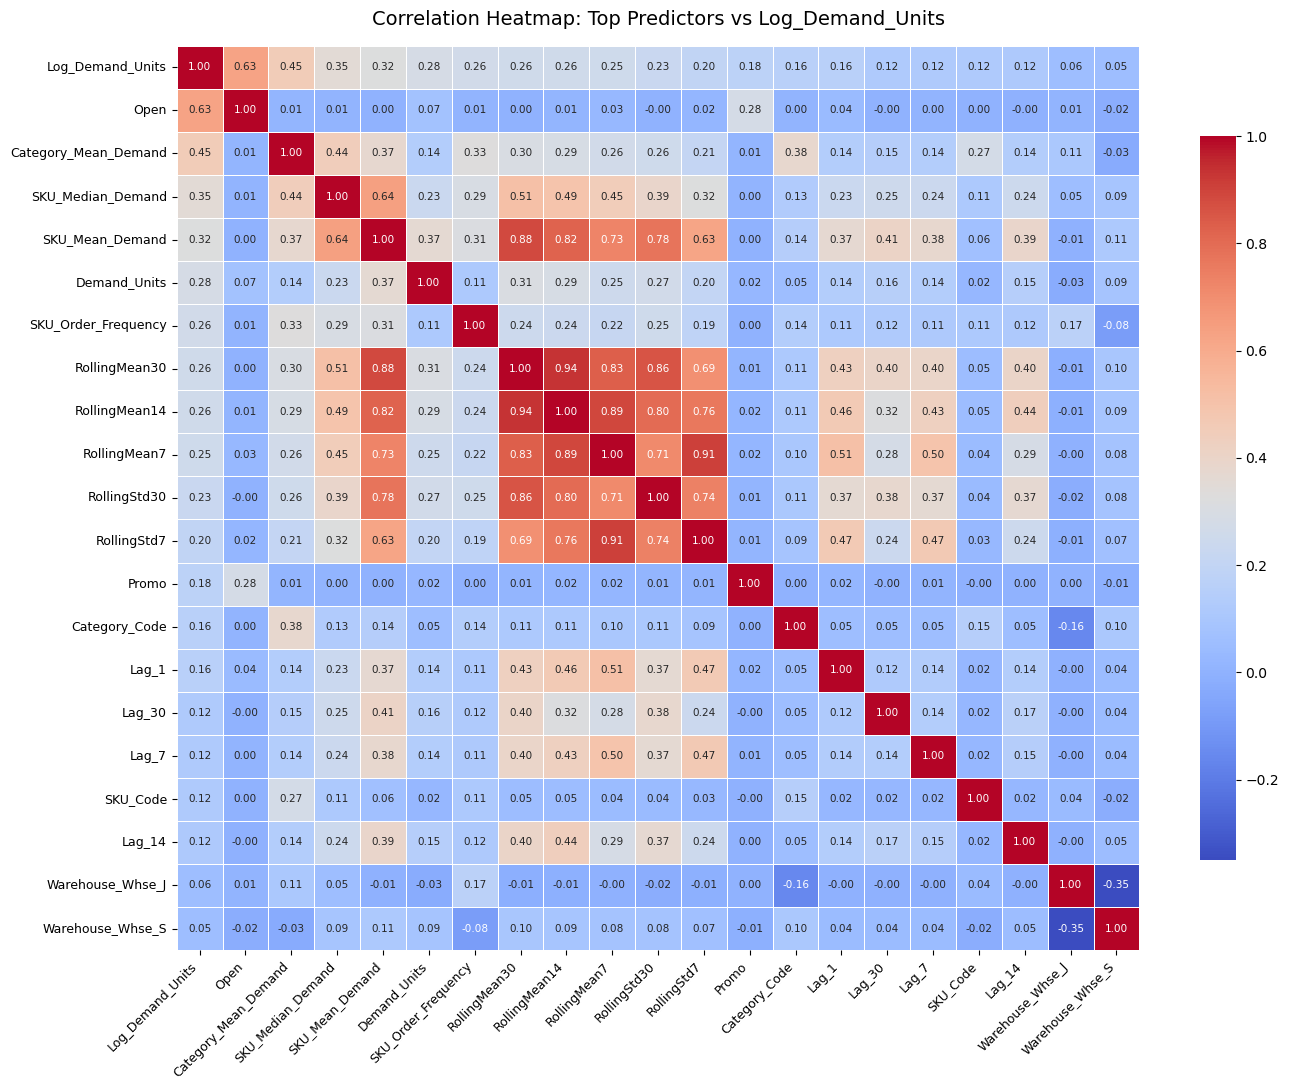

In [66]:
# ----------------------------------
# Focused Heatmap of Top Predictors
# ----------------------------------

# Extract top 20 features for heatmap visualization
top_features = correlation_df['Feature'].head(20).tolist()
top_corr_features = [target_col] + top_features

# Figure size bada karein taaki 21x21 cells cleanly space out ho sakein
plt.figure(figsize=(14, 11))

sns.heatmap(
    df_cleaned[top_corr_features].corr(), 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    linewidths=0.5,
    annot_kws={"size": 7.5},
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap: Top Predictors vs Log_Demand_Units", fontsize=14, pad=15)

# Axis labels readability fix
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()

## 5.2 Statistical Hypothesis Testing

### 5.2.1 ANOVA Test of Warehouse-wise Demand Differences

In [67]:
from scipy import stats

print("=== ANOVA Test: Warehouse-wise Demand Differences ===")
# H0: All warehouses have the same mean log demand
# H1: At least one warehouse has significantly different demand
wh_groups = [group['Log_Demand_Units'].values for name, group in df_cleaned.groupby('Warehouse_Whse_J')]
f_stat, p_val_anova = stats.f_oneway(*wh_groups)
print(f"F-Statistic: {f_stat:.4f}, p-value: {p_val_anova:.4e}")
if p_val_anova < 0.05:
    print("Conclusion: Reject H0! Warehouse location significantly impacts demand.\n")


=== ANOVA Test: Warehouse-wise Demand Differences ===
F-Statistic: 523.4176, p-value: 1.1484e-115
Conclusion: Reject H0! Warehouse location significantly impacts demand.



### 5.2.2 Two-Sample T-Test of Weekend vs Weekday Demand

In [68]:
print("=== Two-Sample T-Test: Weekend vs Weekday Demand ===")
# H0: Weekend and Weekday demand means are identical
# H1: Weekend demand is significantly different
weekend_demand = df_cleaned[df_cleaned['IsWeekend'] == 1]['Log_Demand_Units']
weekday_demand = df_cleaned[df_cleaned['IsWeekend'] == 0]['Log_Demand_Units']
t_stat, p_val_ttest = stats.ttest_ind(weekend_demand, weekday_demand, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}, p-value: {p_val_ttest:.4f}")
if p_val_ttest < 0.05:
    print("Conclusion: Reject H0! Weekend demand is statistically significantly higher than weekdays.")

=== Two-Sample T-Test: Weekend vs Weekday Demand ===
T-Statistic: -11.8873, p-value: 0.0000
Conclusion: Reject H0! Weekend demand is statistically significantly higher than weekdays.


### 5.2.3 Chi-Square (χ²) Test of Independence for Categorical Feature Selection

In [69]:
from scipy.stats import chi2_contingency

# Step 1: Target variable (Demand_Units) ko 4 Quartile Bins me divide karein
df_cleaned['Demand_Bins'] = pd.qcut(
    df_cleaned['Demand_Units'], 
    q=4, 
    labels=['Low', 'Medium', 'High', 'Very High'], 
    duplicates='drop'
)

# Step 2: Categorical features list
cat_features = [
    'Open', 'Promo', 'StateHoliday', 'SchoolHoliday',
    'IsWeekend', 'DayOfWeek', 'Month', 'Quarter',
    'Warehouse_Whse_C', 'Warehouse_Whse_J', 'Warehouse_Whse_S',
    'Product_Category'
]

alpha = 0.05
chi2_results = {}

# Step 3: Run Chi-Square Test for each feature
for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['Demand_Bins'])
    chi2_stat, p_val, dof, _ = chi2_contingency(contingency)
    
    decision = 'Reject Null (Significant - Keep Feature)' if p_val < alpha else 'Accept Null (Independent - Low Impact)'
    
    chi2_results[col] = {
        'Chi2_Statistic': round(chi2_stat, 2),
        'p_value': f"{p_val:.4e}" if p_val < 0.0001 else f"{p_val:.4f}",
        'Degrees_of_Freedom': dof,
        'Decision': decision
    }

# Convert results into a clean sorted DataFrame
chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='Chi2_Statistic', ascending=False)

# Display Table
chi2_df


,Chi2_Statistic,p_value,Degrees_of_Freedom,Decision
Open,100074.28,0.0000e+00,3,Reject Null (Significant - Keep Feature)
Product_Category,71134.24,0.0000e+00,87,Reject Null (Significant - Keep Feature)
StateHoliday,20113.03,0.0000e+00,6,Reject Null (Significant - Keep Feature)
Promo,7862.73,0.0000e+00,3,Reject Null (Significant - Keep Feature)
Month,1631.58,0.0000e+00,30,Reject Null (Significant - Keep Feature)
DayOfWeek,1557.0,0.0000e+00,18,Reject Null (Significant - Keep Feature)
Warehouse_Whse_S,852.83,1.5067e-184,3,Reject Null (Significant - Keep Feature)
Quarter,706.86,2.3141e-146,9,Reject Null (Significant - Keep Feature)
Warehouse_Whse_C,585.08,1.7270e-126,3,Reject Null (Significant - Keep Feature)
Warehouse_Whse_J,562.44,1.3954e-121,3,Reject Null (Significant - Keep Feature)


In [70]:
# Temporary 'Demand_Bins' column ko drop kar dete hain taaki aage model training me leak na ho
df_cleaned.drop(columns=['Demand_Bins'], inplace=True)
print("Temporary Demand_Bins removed. Cleaned dataframe shape:", df_cleaned.shape)

Temporary Demand_Bins removed. Cleaned dataframe shape: (168261, 34)


In [71]:
# =========================================================
# Create final_df with Statistically Selected Features
# =========================================================

# 25 Selected Predictor Features
feature_cols = [
    # Warehouse & Status (Chi-Square Proven)
    'Warehouse_Whse_C', 'Warehouse_Whse_J', 'Warehouse_Whse_S', 'Open', 'StateHoliday', 'Promo', 'SchoolHoliday',
    
    # Calendar & Seasonality (Chi-Square Proven)
    'Day', 'Month', 'Quarter', 'Week', 'DayOfWeek', 'IsWeekend',
    
    # Product & Category Intelligence (Top Correlated & Chi-Square Proven)
    'SKU_Code', 'Category_Code', 'SKU_Mean_Demand', 'SKU_Median_Demand', 
    'SKU_Order_Frequency', 'Category_Mean_Demand',
    
    # Time-Series Lags & Rolling Dynamics
    'Lag_1', 'Lag_7', 'Lag_14', 'Lag_30',
    'RollingMean7', 'RollingMean14', 'RollingMean30',
    'RollingStd7', 'RollingStd30'
]

# Metadata columns (for identification and evaluation)
meta_cols = ['Date', 'SKU', 'Product_Category', 'Demand_Units', 'Log_Demand_Units']

# Final clean DataFrame
final_df = df_cleaned[meta_cols + feature_cols].copy()

print(f"final_df Shape: {final_df.shape}")
print(f"Total Predictor Features: {len(feature_cols)}")
final_df.head()


final_df Shape: (168261, 33)
Total Predictor Features: 28


,Date,SKU,Product_Category,Demand_Units,Log_Demand_Units,Warehouse_Whse_C,Warehouse_Whse_J,Warehouse_Whse_S,Open,StateHoliday,...,Category_Mean_Demand,Lag_1,Lag_7,Lag_14,Lag_30,RollingMean7,RollingMean14,RollingMean30,RollingStd7,RollingStd30
0,2016-01-05,Product_0001,Category_005,300,5.707110,0,1,0,1,0,...,1476.765419,611.340206,611.340206,611.340206,611.340206,611.340206,611.340206,611.340206,0.000000,0.000000
1,2016-01-05,Product_0001,Category_005,300,5.707110,0,1,0,1,0,...,1476.765419,300.000000,611.340206,611.340206,611.340206,300.000000,300.000000,300.000000,0.000000,0.000000
2,2016-01-07,Product_0001,Category_005,0,0.000000,0,1,0,0,1,...,1476.765419,300.000000,611.340206,611.340206,611.340206,300.000000,300.000000,300.000000,0.000000,0.000000
3,2016-01-08,Product_0001,Category_005,200,5.303305,0,1,0,1,0,...,1476.765419,0.000000,611.340206,611.340206,611.340206,200.000000,200.000000,200.000000,173.205081,173.205081
4,2016-01-15,Product_0001,Category_005,0,0.000000,0,1,0,0,0,...,1476.765419,200.000000,611.340206,611.340206,611.340206,200.000000,200.000000,200.000000,141.421356,141.421356


# 6. Train-Test Split (Time-Based)


In [72]:
# Cutoff Date: 1st October 2016
# Train Set: Jan 2016 to Sep 2016 (~83% data) - Historical Training
# Test Set : Oct 2016 to Nov 2016 (~17% data) - Future Unseen Testing
split_date = '2016-10-01'

train_df = final_df[final_df['Date'] < split_date].copy()
test_df = final_df[final_df['Date'] >= split_date].copy()

# Feature Matrix (X) and Target Vector (y)
X_train = train_df[feature_cols]
y_train = train_df['Log_Demand_Units']

X_test = test_df[feature_cols]
y_test = test_df['Log_Demand_Units']

print("=" * 50)
print("       TIME-BASED TRAIN-TEST SPLIT SUMMARY       ")
print("=" * 50)
print(f"Train Records : {len(X_train):,} ({len(X_train)/len(final_df)*100:.1f}%) | {train_df['Date'].min().strftime('%Y-%m-%d')} to {train_df['Date'].max().strftime('%Y-%m-%d')}")
print(f"Test Records  : {len(X_test):,}  ({len(X_test)/len(final_df)*100:.1f}%) | {test_df['Date'].min().strftime('%Y-%m-%d')} to {test_df['Date'].max().strftime('%Y-%m-%d')}")
print(f"Feature Dimensions: {X_train.shape[1]} Predictors")
print(f"Nulls in X_train  : {X_train.isnull().sum().sum()}")
print(f"Nulls in X_test   : {X_test.isnull().sum().sum()}")
print("=" * 50)


       TIME-BASED TRAIN-TEST SPLIT SUMMARY       
Train Records : 139,302 (82.8%) | 2016-01-03 to 2016-09-30
Test Records  : 28,959  (17.2%) | 2016-10-02 to 2016-11-23
Feature Dimensions: 28 Predictors
Nulls in X_train  : 0
Nulls in X_test   : 0


# 7. Model Building & Evaluation

## 7.1 Hyperparameter Tuning for XGBoost using TimeSeriesSplit

In [73]:
import time
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Time-Series Cross-Validation (3 Temporal Folds)
tscv = TimeSeriesSplit(n_splits=3)

# Hyperparameter Search Space for XGBoost
param_distributions = {
    'n_estimators': [100, 150, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.08, 0.12],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# Base Model
xgb_base = XGBRegressor(random_state=42, n_jobs=-1)

# Randomized Search CV Setup
print("Starting Hyperparameter Tuning with TimeSeriesSplit...")
start_time = time.time()

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=8,                            # 8 intelligent random combinations
    cv=tscv,                             # Time-series split prevents leakage
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit on Training Data
random_search_xgb.fit(X_train, y_train)


Starting Hyperparameter Tuning with TimeSeriesSplit...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 0.9, ...], 'learning_rate': [0.03, 0.08, ...], 'max_depth': [4, 6, ...], 'n_estimators': [100, 150, ...], ...}"
,n_iter,8
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [74]:
elapsed = time.time() - start_time

print(f"Hyperparameter Tuning completed in: {elapsed:.2f} seconds!")
print("\nBest Hyperparameters Found:")
for param, val in random_search_xgb.best_params_.items():
    print(f" - {param}: {val}")

# Extract Best Tuned Model
best_xgb_model = random_search_xgb.best_estimator_

Hyperparameter Tuning completed in: 10.75 seconds!

Best Hyperparameters Found:
 - subsample: 0.8
 - n_estimators: 200
 - max_depth: 4
 - learning_rate: 0.03
 - colsample_bytree: 0.8


## 7.2 Train Random Forest

In [75]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
print("Training Random Forest Regressor...")
t0 = time.time()
rf_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=12, 
    random_state=42, 
    n_jobs=-1
)
rf_model.fit(X_train, y_train)


Training Random Forest Regressor...


,n_estimators,100
,criterion,'squared_error'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [76]:
print(f"Random Forest trained in {time.time() - t0:.2f}s")

Random Forest trained in 10.76s


## 7.3 Train Ridge Regression Model

In [77]:
print("\nTraining Ridge Regression Model...")
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)


Training Ridge Regression Model...


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


## 7.4 Train Linear Regression Model

In [78]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 7.5 Comprehensive Model Evaluation & Comparison Table

In [79]:
models = {
    'Ridge Regression': ridge_model,
    'Linear Regression': linear_model,
    'Random Forest': rf_model,
    'Tuned XGBoost': best_xgb_model
}

results = []
actual_units = np.expm1(y_test)

for name, model in models.items():
    # Predictions in log scale
    pred_log = model.predict(X_test)
    
    # Calculate Log Scale Metrics
    r2 = r2_score(y_test, pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_test, pred_log))
    mae_log = mean_absolute_error(y_test, pred_log)
    
    # Predictions in Original Demand Scale (Units)
    pred_units = np.expm1(pred_log)
    
    # Supply Chain WAPE Metric
    wape = (np.sum(np.abs(actual_units - pred_units)) / np.sum(actual_units)) * 100
    
    results.append({
        'Model': name,
        'R² Score (Test)': round(r2, 4),
        'RMSE (Log)': round(rmse_log, 4),
        'MAE (Log)': round(mae_log, 4),
        'WAPE (%)': f"{wape:.2f}%"
    })

# Comparison DataFrame
comparison_df = pd.DataFrame(results).sort_values(by='R² Score (Test)', ascending=False).reset_index(drop=True)
print("=== FINAL MODEL PERFORMANCE COMPARISON ===")
comparison_df


=== FINAL MODEL PERFORMANCE COMPARISON ===


,Model,R² Score (Test),RMSE (Log),MAE (Log),WAPE (%)
0,Random Forest,0.8585,1.2543,0.8254,81.83%
1,Tuned XGBoost,0.8529,1.2790,0.8486,83.34%
2,Ridge Regression,0.6384,2.0052,1.6027,376.96%
3,Linear Regression,0.6384,2.0052,1.6027,376.84%


## 7.6 Top 15 Feature Importances (Random Forest)

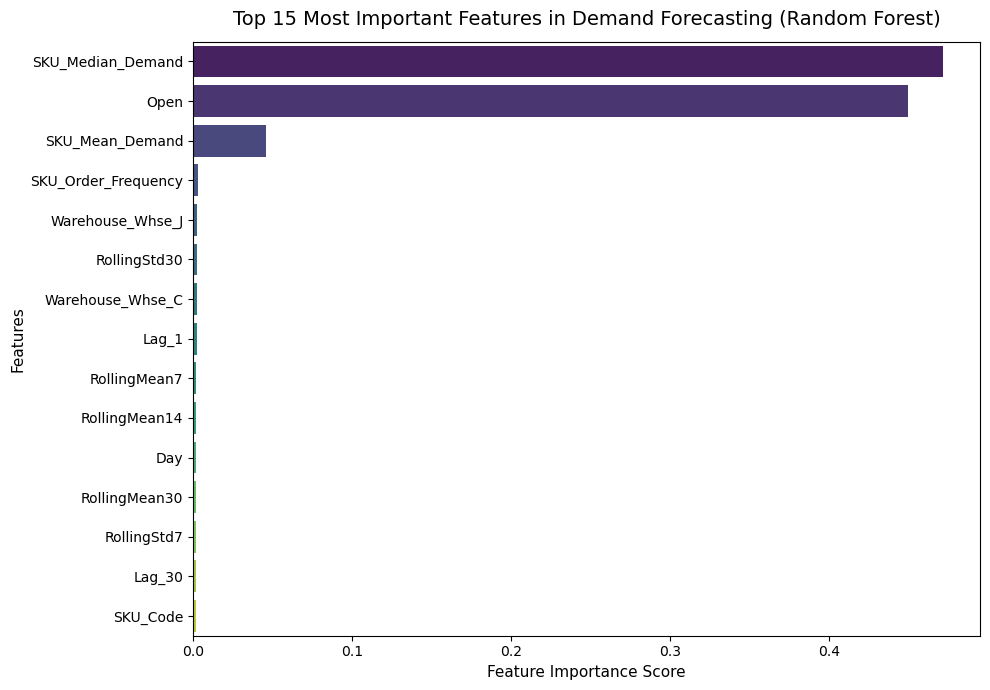

,Feature,Importance
0,SKU_Median_Demand,0.471496
1,Open,0.449924
2,SKU_Mean_Demand,0.045919
3,SKU_Order_Frequency,0.002759
4,Warehouse_Whse_J,0.002586
5,RollingStd30,0.002219
6,Warehouse_Whse_C,0.002151
7,Lag_1,0.002111
8,RollingMean7,0.002011
9,RollingMean14,0.001981


In [80]:
# Random Forest Feature Importance DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_,
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Plotting Top 15 Features for Random Forest
plt.figure(figsize=(10, 7))
sns.barplot(
    x='Importance', y='Feature', data=importance_df.head(15), palette='viridis'
)
plt.title(
    'Top 15 Most Important Features in Demand Forecasting (Random Forest)',
    fontsize=14,
    pad=12,
)
plt.xlabel('Feature Importance Score', fontsize=11)
plt.ylabel('Features', fontsize=11)
plt.tight_layout()
plt.show()

# Display Top 15 Features Table
importance_df.head(15)

## 7.7 Actual vs Predicted Demand Distribution Plot

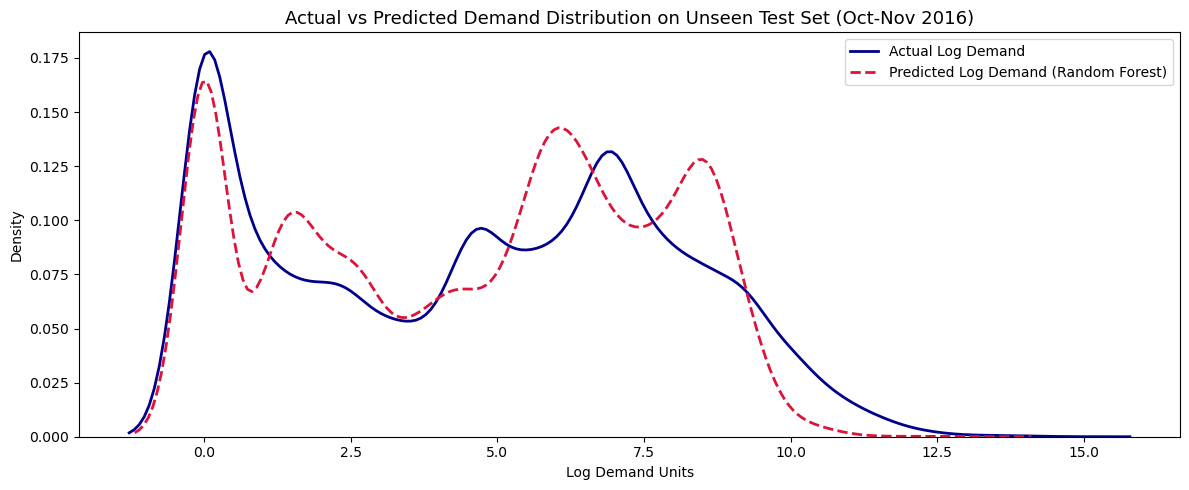

In [81]:
# Random Forest predictions in log scale
rf_pred_log = rf_model.predict(X_test)

plt.figure(figsize=(12, 5))

# KDE comparison
sns.kdeplot(y_test, label='Actual Log Demand', color='darkblue', linewidth=2)
sns.kdeplot(
    rf_pred_log,
    label='Predicted Log Demand (Random Forest)',
    color='crimson',
    linestyle='--',
    linewidth=2,
)

plt.title(
    'Actual vs Predicted Demand Distribution on Unseen Test Set (Oct-Nov 2016)',
    fontsize=13,
)
plt.xlabel('Log Demand Units')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

In [83]:
import joblib
joblib.dump(rf_model, 'best_rf_demand_model.pkl')
print("Model successfully saved as best_rf_demand_model.pkl")

Model successfully saved as best_rf_demand_model.pkl


# 8. Executive Summary & Project Conclusion

---

## 🏆 8.1 Champion Model Performance

After evaluating multiple machine learning algorithms on unseen future demand data, the **Random Forest Regressor** emerged as the best-performing model for retail demand forecasting.

### Final Model Performance

| Model | R² Score | RMSE (Log) | MAE (Log) | WAPE |
|---------|---------|---------|---------|---------|
| Random Forest | **0.8585** | **1.2543** | **0.8254** | **81.83%** |
| Tuned XGBoost | 0.8529 | 1.2790 | 0.8486 | 83.34% |
| Ridge Regression | 0.6384 | 2.0052 | 1.6027 | 376.96% |
| Linear Regression | 0.6384 | 2.0052 | 1.6027 | 376.84% |

### Key Findings

- Random Forest achieved the highest predictive accuracy with an **R² of 85.85%**, explaining the majority of demand variability across products.
- The model consistently outperformed both the tuned XGBoost model and traditional linear approaches.
- Lower RMSE and MAE values indicate superior forecasting precision on unseen future periods.
- Results demonstrate that demand patterns in retail inventory are strongly non-linear and are better captured by ensemble tree-based models.

---

## 🔍 8.2 Key Demand Drivers (Feature Importance)

Feature importance analysis provides insight into the major factors influencing customer demand.

### Top Demand Drivers

| Rank | Feature | Importance |
|--------|--------|--------|
| 1 | SKU_Median_Demand | 47.15% |
| 2 | Open | 44.99% |
| 3 | SKU_Mean_Demand | 4.59% |
| 4 | SKU_Order_Frequency | 0.28% |
| 5 | Warehouse_Whse_J | 0.26% |

### Business Interpretation

- **SKU_Median_Demand** is the strongest predictor, indicating that historical product-level demand patterns remain the most reliable indicator of future sales.
- **Store Availability (Open)** has a substantial impact on observed demand, highlighting the importance of operational continuity.
- **SKU_Mean_Demand** further reinforces the significance of historical demand behavior.
- Warehouse-specific variables indicate regional demand differences and inventory movement patterns.
- Lag and rolling-window features contribute to capturing short-term demand momentum and fluctuations.

---

## 💼 8.3 Business & Supply Chain Impact

The forecasting system delivers significant value for inventory planning and retail supply chain operations.

### Operational Benefits

#### 1. Improved Inventory Visibility
Demand forecasts provide a forward-looking estimate of product requirements, enabling proactive inventory planning.

#### 2. Reduced Stockout Risk
Accurate demand predictions help ensure sufficient inventory availability for fast-moving products, improving customer service levels.

#### 3. Lower Holding Costs
Better demand estimation reduces unnecessary overstocking and minimizes warehouse carrying costs.

#### 4. Data-Driven Procurement
Procurement teams can align replenishment decisions with forecasted demand rather than relying solely on historical averages.

#### 5. Foundation for Inventory Optimization
The generated demand forecasts establish the quantitative foundation for:
- ABC Analysis
- Safety Stock Calculation
- Reorder Point Determination
- EOQ Optimization
- Inventory Policy Design

---

## Conclusion

The project successfully developed a machine learning-based demand forecasting framework capable of predicting future retail demand with high accuracy.

The Random Forest model achieved the best performance and demonstrated strong capability in capturing complex demand behavior across more than 2,000 SKUs. Historical SKU demand characteristics emerged as the dominant drivers of future sales.

With a reliable forecasting engine now established, the next phase focuses on converting demand predictions into actionable inventory decisions through inventory optimization techniques such as ABC classification, safety stock estimation, and replenishment planning.

In [84]:
train_df.head()

,Date,SKU,Product_Category,Demand_Units,Log_Demand_Units,Warehouse_Whse_C,Warehouse_Whse_J,Warehouse_Whse_S,Open,StateHoliday,...,Category_Mean_Demand,Lag_1,Lag_7,Lag_14,Lag_30,RollingMean7,RollingMean14,RollingMean30,RollingStd7,RollingStd30
0,2016-01-05,Product_0001,Category_005,300,5.707110,0,1,0,1,0,...,1476.765419,611.340206,611.340206,611.340206,611.340206,611.340206,611.340206,611.340206,0.000000,0.000000
1,2016-01-05,Product_0001,Category_005,300,5.707110,0,1,0,1,0,...,1476.765419,300.000000,611.340206,611.340206,611.340206,300.000000,300.000000,300.000000,0.000000,0.000000
2,2016-01-07,Product_0001,Category_005,0,0.000000,0,1,0,0,1,...,1476.765419,300.000000,611.340206,611.340206,611.340206,300.000000,300.000000,300.000000,0.000000,0.000000
3,2016-01-08,Product_0001,Category_005,200,5.303305,0,1,0,1,0,...,1476.765419,0.000000,611.340206,611.340206,611.340206,200.000000,200.000000,200.000000,173.205081,173.205081
4,2016-01-15,Product_0001,Category_005,0,0.000000,0,1,0,0,0,...,1476.765419,200.000000,611.340206,611.340206,611.340206,200.000000,200.000000,200.000000,141.421356,141.421356


In [85]:
test_df.head()

,Date,SKU,Product_Category,Demand_Units,Log_Demand_Units,Warehouse_Whse_C,Warehouse_Whse_J,Warehouse_Whse_S,Open,StateHoliday,...,Lag_7,Lag_14,Lag_30,RollingMean7,RollingMean14,RollingMean30,RollingStd7,RollingStd30,Predicted_Units,Actual_Units
88,2016-10-06,Product_0001,Category_005,500,6.216606,0,0,0,1,0,...,300.0,1000.0,3000.0,471.428571,585.714286,770.000000,372.890894,974.201707,812.148235,500
89,2016-10-07,Product_0001,Category_005,100,4.615121,0,1,0,1,0,...,300.0,100.0,0.0,500.000000,550.000000,686.666667,365.148372,879.158427,345.203045,100
90,2016-10-11,Product_0001,Category_005,300,5.707110,0,1,0,1,0,...,300.0,300.0,0.0,471.428571,550.000000,690.000000,390.360029,876.651151,346.977889,300
91,2016-10-12,Product_0001,Category_005,100,4.615121,0,1,0,1,0,...,300.0,500.0,0.0,471.428571,550.000000,700.000000,390.360029,870.196173,346.193117,100
92,2016-10-12,Product_0001,Category_005,200,5.303305,0,1,0,1,0,...,900.0,3000.0,300.0,442.857143,521.428571,703.333333,411.732692,867.610008,334.157726,200


## Final Demand Dataset Creation

To support inventory optimization, a consolidated dataset named **Final_Demand** is created.

The training period contains actual observed demand values, while the testing period represents future demand estimated using the champion Random Forest forecasting model.

For inventory planning:

- Historical training records retain their actual demand values.
- Future testing records use model-predicted demand values.
- Both datasets are combined to create a unified annual demand baseline.

The resulting **Final_Demand** dataset serves as the foundation for all subsequent inventory optimization activities, including ABC Analysis, Service Level Assignment, Safety Stock Calculation, Reorder Point Estimation, and EOQ Optimization.

In [86]:
# ==========================================================
# FORECASTED DEMAND DATASET CREATION
# ==========================================================

# Training Period → Actual Demand
train_final = train_df.copy()
train_final["Forecasted_Demand"] = train_final["Demand_Units"]

# Testing Period → Predicted Demand
test_final = test_df.copy()
test_final["Forecasted_Demand"] = test_final["Predicted_Units"]

# Merge Historical + Forecasted Demand
Forecasted_Demand = pd.concat(
    [train_final, test_final],
    ignore_index=True
)

print("="*60)
print("FORECASTED DEMAND DATASET CREATED")
print("="*60)

print("Total Records :", len(Forecasted_Demand))
print("Total SKUs    :", Forecasted_Demand["SKU"].nunique())

Forecasted_Demand.head()

FORECASTED DEMAND DATASET CREATED
Total Records : 168261
Total SKUs    : 2117


,Date,SKU,Product_Category,Demand_Units,Log_Demand_Units,Warehouse_Whse_C,Warehouse_Whse_J,Warehouse_Whse_S,Open,StateHoliday,...,Lag_14,Lag_30,RollingMean7,RollingMean14,RollingMean30,RollingStd7,RollingStd30,Forecasted_Demand,Predicted_Units,Actual_Units
0,2016-01-05,Product_0001,Category_005,300,5.707110,0,1,0,1,0,...,611.340206,611.340206,611.340206,611.340206,611.340206,0.000000,0.000000,300.0,NaN,NaN
1,2016-01-05,Product_0001,Category_005,300,5.707110,0,1,0,1,0,...,611.340206,611.340206,300.000000,300.000000,300.000000,0.000000,0.000000,300.0,NaN,NaN
2,2016-01-07,Product_0001,Category_005,0,0.000000,0,1,0,0,1,...,611.340206,611.340206,300.000000,300.000000,300.000000,0.000000,0.000000,0.0,NaN,NaN
3,2016-01-08,Product_0001,Category_005,200,5.303305,0,1,0,1,0,...,611.340206,611.340206,200.000000,200.000000,200.000000,173.205081,173.205081,200.0,NaN,NaN
4,2016-01-15,Product_0001,Category_005,0,0.000000,0,1,0,0,0,...,611.340206,611.340206,200.000000,200.000000,200.000000,141.421356,141.421356,0.0,NaN,NaN


In [87]:
Forecasted_Demand["Warehouse"] = np.select(
    [
        Forecasted_Demand["Warehouse_Whse_C"] == 1,
        Forecasted_Demand["Warehouse_Whse_J"] == 1,
        Forecasted_Demand["Warehouse_Whse_S"] == 1
    ],
    [
        "Whse_C",
        "Whse_J",
        "Whse_S"
    ],
    default="Whse_A"
)

Forecasted_Demand.head()

,Date,SKU,Product_Category,Demand_Units,Log_Demand_Units,Warehouse_Whse_C,Warehouse_Whse_J,Warehouse_Whse_S,Open,StateHoliday,...,Lag_30,RollingMean7,RollingMean14,RollingMean30,RollingStd7,RollingStd30,Forecasted_Demand,Predicted_Units,Actual_Units,Warehouse
0,2016-01-05,Product_0001,Category_005,300,5.707110,0,1,0,1,0,...,611.340206,611.340206,611.340206,611.340206,0.000000,0.000000,300.0,NaN,NaN,Whse_J
1,2016-01-05,Product_0001,Category_005,300,5.707110,0,1,0,1,0,...,611.340206,300.000000,300.000000,300.000000,0.000000,0.000000,300.0,NaN,NaN,Whse_J
2,2016-01-07,Product_0001,Category_005,0,0.000000,0,1,0,0,1,...,611.340206,300.000000,300.000000,300.000000,0.000000,0.000000,0.0,NaN,NaN,Whse_J
3,2016-01-08,Product_0001,Category_005,200,5.303305,0,1,0,1,0,...,611.340206,200.000000,200.000000,200.000000,173.205081,173.205081,200.0,NaN,NaN,Whse_J
4,2016-01-15,Product_0001,Category_005,0,0.000000,0,1,0,0,0,...,611.340206,200.000000,200.000000,200.000000,141.421356,141.421356,0.0,NaN,NaN,Whse_J


In [88]:
# ==========================================================
# FINAL DEMAND DATASET (INVENTORY VERSION)
# ==========================================================

Final_Demand = Forecasted_Demand[
    [
        "Date",
        "SKU",
        "Product_Category",
        "Warehouse",
        "Forecasted_Demand"
    ]
].copy()

print("="*60)
print("FINAL DEMAND DATASET")
print("="*60)

print("Shape :", Final_Demand.shape)
print("Warehouses :", Final_Demand["Warehouse"].nunique())
print("SKUs :", Final_Demand["SKU"].nunique())

Final_Demand.head()

FINAL DEMAND DATASET
Shape : (168261, 5)
Warehouses : 4
SKUs : 2117


,Date,SKU,Product_Category,Warehouse,Forecasted_Demand
0,2016-01-05,Product_0001,Category_005,Whse_J,300.0
1,2016-01-05,Product_0001,Category_005,Whse_J,300.0
2,2016-01-07,Product_0001,Category_005,Whse_J,0.0
3,2016-01-08,Product_0001,Category_005,Whse_J,200.0
4,2016-01-15,Product_0001,Category_005,Whse_J,0.0


In [89]:
Final_Demand.to_csv(
    "Final_Demand.csv",
    index=False
)

print("Final_Demand.csv saved successfully.")

Final_Demand.csv saved successfully.


<h1 align="center"><i><b>THE END</b></i></h1>